# 2 概述、线性代数和 NDArray

## 2.1 理论计算题

已知向量 $\mathbf{a} = [2, -1, 3]^\top$, $\mathbf{b} = [1, 4, -2]^\top$，矩阵
$$ A = \begin{bmatrix} 1 & 0 & 2 \\ -1 & 3 & 1 \end{bmatrix}, B = \begin{bmatrix} 2 & 1 \\ 0 & -1 \\ 3 & 2 \end{bmatrix} $$

**1. 向量点积 $\mathbf{a} \cdot \mathbf{b}$：**
$$ \mathbf{a} \cdot \mathbf{b} = 2 \times 1 + (-1) \times 4 + 3 \times (-2) = 2 - 4 - 6 = -8 $$

**2. 矩阵乘法 $A \times B$ 及结果矩阵的形状：**
$$ A \times B = \begin{bmatrix} 1\times2+0\times0+2\times3 & 1\times1+0\times(-1)+2\times2 \\ (-1)\times2+3\times0+1\times3 & (-1)\times1+3\times(-1)+1\times2 \end{bmatrix} = \begin{bmatrix} 8 & 5 \\ 1 & -2 \end{bmatrix} $$
$A$ 的形状为 $2 \times 3$，$B$ 的形状为 $3 \times 2$，因此**结果矩阵的形状为 $2 \times 2$**。

**3. 向量 $\mathbf{a}$ 的 Frobenius 范数：**
向量的 Frobenius 范数即为其 $L_2$ 范数：
$$ \|\mathbf{a}\|_F = \sqrt{2^2 + (-1)^2 + 3^2} = \sqrt{4 + 1 + 9} = \sqrt{14} \approx 3.742 $$

## 2.2 编程题
使用 NumPy 完成以下任务：
1. 创建一个形状为 $3 \times 4$ 的随机矩阵 $X$，元素服从标准正态分布。
2. 创建一个形状为 $4 \times 2$ 的全 1 矩阵 $Y$。
3. 计算矩阵乘法 $Z = X \times Y$。
4. 输出 $Z$ 的第一行和第二列交叉处的元素，以及 $Z$ 的第 2 行所有元素。
5. 计算 $Z$ 的 Frobenius 范数。

In [1]:
import numpy as np

# 1. 创建形状为 3x4 的随机标准正态分布矩阵 X
X = np.random.randn(3, 4)
print("X:\n", X)

# 2. 创建形状为 4x2 的全1矩阵 Y
Y = np.ones((4, 2))
print("\nY:\n", Y)

# 3. 计算矩阵乘法 Z = X @ Y
Z = X @ Y
print("\nZ (X @ Y):\n", Z)

# 4. 输出 Z 第一行第二列，以及 Z 第二行的所有元素（注意：Python 索引从0开始）
print("\nZ 第1行第2列元素 (Z[0, 1]):", Z[0, 1])
print("Z 第2行所有元素 (Z[1, :]):", Z[1, :])

# 5. 计算 Z 的 Frobenius 范数
frobenius_norm = np.linalg.norm(Z, 'fro')
print("\nZ 的 Frobenius 范数:", frobenius_norm)

X:
 [[-1.31724231 -0.9876938  -1.21598708  1.95234942]
 [ 1.18491171  0.63552884 -0.88056037 -0.58005237]
 [-1.63843429  0.22932921 -1.05865794 -0.00386269]]

Y:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z (X @ Y):
 [[-1.56857376 -1.56857376]
 [ 0.35982781  0.35982781]
 [-2.47162571 -2.47162571]]

Z 第1行第2列元素 (Z[0, 1]): -1.5685737603621548
Z 第2行所有元素 (Z[1, :]): [0.35982781 0.35982781]

Z 的 Frobenius 范数: 4.171051032054666


# 3 文档 2：概率与统计

## 3.1 理论计算题

已知：
- $P(D) = 0.001$ （患病率）；
- $P(\neg D) = 0.999$ （未患病率）；
- $P(+ | D) = 0.99$ （患病时检测呈阳性的概率即灵敏度）；
- $P(+ | \neg D) = 0.02$ （未患病时检测呈阳性的概率即假阳性率）。

根据**全概率公式**，检测结果为阳性的总概率为：
$$ P(+) = P(+ | D)P(D) + P(+ | \neg D)P(\neg D) $$
$$ P(+) = (0.99 \times 0.001) + (0.02 \times 0.999) = 0.00099 + 0.01998 = 0.02097 $$

根据**贝叶斯公式**，一个人检测结果为阳性时，其真正患病的概率为：
$$ P(D | +) = \frac{P(+ | D)P(D)}{P(+)} = \frac{0.00099}{0.02097} \approx 0.04721 $$
**答**：他真正患病的概率约为 $4.72\%$。

## 3.2 编程题
用 Python 模拟中心极限定理：
1. 生成 $n = 10000$ 个服从均匀分布 $U(0,1)$ 的随机变量，重复 $m = 1000$ 次，每次计算这 $n$ 个变量的均值。
2. 绘制这 $1000$ 个均值的直方图，并叠加理论正态分布的概率密度曲线。
3. 计算这些均值的实际方差。

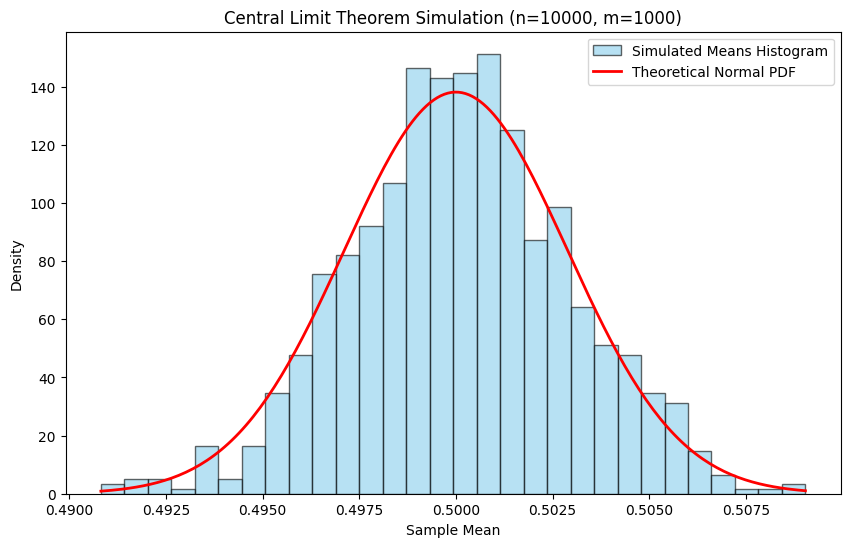

实际方差 (Actual Variance):      8.104044959706716e-06
理论方差 (Theoretical Variance): 8.333333333333332e-06


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

m = 1000
n = 10000

# 1. 重复生成 m 次，每次有 n 个服从 U(0,1) 的均匀随机变量，计算每组均值
# 避免循环，我们可以使用 numpy 向量化一次性生成 m x n 的矩阵再沿列方向求均值
U = np.random.uniform(0, 1, size=(m, n))
means = U.mean(axis=1)

# 2. 绘制 1000 个均值的直方图及理论正态曲线
# 均匀分布 U(0,1) 理论均值为 0.5，理论方差为 1/12
mu_theory = 0.5
var_theory = (1/12) / n
sigma_theory = np.sqrt(var_theory)

plt.figure(figsize=(10, 6))

counts, bins, _ = plt.hist(means, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label="Simulated Means Histogram")

x_vals = np.linspace(bins[0], bins[-1], 200)
pdf_theory = stats.norm.pdf(x_vals, loc=mu_theory, scale=sigma_theory)
plt.plot(x_vals, pdf_theory, color='red', lw=2, label="Theoretical Normal PDF")

plt.title(f"Central Limit Theorem Simulation (n={n}, m={m})")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.legend()
plt.show()

# 3. 计算均值的实际方差并与理论方差对比
var_actual = np.var(means, ddof=1)  # 样本方差，无偏估计
print("实际方差 (Actual Variance):     ", var_actual)
print("理论方差 (Theoretical Variance):", var_theory)

# 4 文档 3：导数、反向传播和复杂度

## 4.1 理论计算题

给定函数 $z = (w_1 x_1 + w_2 x_2 - y)^2$，常数 $x_1 = 2, x_2 = 1, y = 3$，变量为 $w_1, w_2$。

**1. 分别计算 $\frac{\partial z}{\partial w_1}$ 和 $\frac{\partial z}{\partial w_2}$ 的表达式：**

设 $u = w_1 x_1 + w_2 x_2 - y$，则 $z = u^2$。

根据链式法则：
$$ \frac{\partial z}{\partial w_1} = \frac{\partial z}{\partial u} \frac{\partial u}{\partial w_1} = 2u \cdot x_1 = 2(w_1 x_1 + w_2 x_2 - y) x_1 $$
$$ \frac{\partial z}{\partial w_2} = \frac{\partial z}{\partial u} \frac{\partial u}{\partial w_2} = 2u \cdot x_2 = 2(w_1 x_1 + w_2 x_2 - y) x_2 $$

**2. 计算偏导数的值（当 $w_1 = 0.5, w_2 = 1$ 时）：**
令 $w_1 = 0.5, w_2 = 1$：
代入计算 $u = (0.5 \times 2) + (1 \times 1) - 3 = 1 + 1 - 3 = -1$。

$$ \frac{\partial z}{\partial w_1} = 2 \times (-1) \times 2 = -4 $$
$$ \frac{\partial z}{\partial w_2} = 2 \times (-1) \times 1 = -2 $$
所以，梯度 $\nabla z = [-4, -2]^\top$。

## 4.2 编程题
手动实现计算图的反向传播并与自动微分验证：
1. `a = x * w1`
2. `b = a + w2`
3. `L = b^2`

In [3]:
import torch

# 前向计算参数
x_val = 2.0
w1_val = 1.5
w2_val = 0.5

# 1. 自动微分工具 (PyTorch) 计算
x_t = torch.tensor(x_val, requires_grad=False)
w1_t = torch.tensor(w1_val, requires_grad=True)
w2_t = torch.tensor(w2_val, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

# 计算前向结果并反向传播
print("1. 前向结果 (PyTorch):", L_t.item())
L_t.backward()
print(f"   PyTorch 自动微分梯度 - dL/dw1: {w1_t.grad.item():.4f}, dL/dw2: {w2_t.grad.item():.4f}")

# 2. 手动反向传播
print("\n2. 手动实现前向与反向传播:")
# 前向计算
a = x_val * w1_val
b = a + w2_val
L = b ** 2
print("   前向结果 (手动):", L)

# 反向计算梯度
# L = b^2，则 dL/db = 2*b
dL_db = 2 * b
# b = a + w2，则 db/da = 1, db/dw2 = 1
db_da = 1.0
db_dw2 = 1.0
# a = x * w1，则 da/dw1 = x
da_dw1 = x_val

# 链式法则求 dL/dw1 和 dL/dw2
dL_dw1 = dL_db * db_da * da_dw1
dL_dw2 = dL_db * db_dw2

print(f"   手动实现链式求导 - dL/dw1: {dL_dw1:.4f}, dL/dw2: {dL_dw2:.4f}")

# 验证一致性
is_w1_match = abs(w1_t.grad.item() - dL_dw1) < 1e-6
is_w2_match = abs(w2_t.grad.item() - dL_dw2) < 1e-6
print(f"\n3. 与自动微分结果是否一致: dL/dw1 -> {is_w1_match}, dL/dw2 -> {is_w2_match}")

1. 前向结果 (PyTorch): 12.25
   PyTorch 自动微分梯度 - dL/dw1: 14.0000, dL/dw2: 7.0000

2. 手动实现前向与反向传播:
   前向结果 (手动): 12.25
   手动实现链式求导 - dL/dw1: 14.0000, dL/dw2: 7.0000

3. 与自动微分结果是否一致: dL/dw1 -> True, dL/dw2 -> True


# 5 文档 4：线性方法、基础优化和 softmax 回归

## 5.1 理论计算题

考虑线性回归模型 $y = wx + b$，使用均方误差损失：
$$ L = \frac{1}{n} \sum_{i=1}^n (y_i - (wx_i + b))^2 $$

推导损失对 $w$ 和 $b$ 的偏导数表达式（利用求和形式）：

应用链式法则：令 $f(w, b, x_i) = y_i - (wx_i + b)$。
损失对 $w$ 的导数：
$$ \frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^n 2(y_i - (w x_i + b)) \cdot \frac{\partial (y_i - w x_i - b)}{\partial w} $$
由于 $\frac{\partial (y_i - w x_i - b)}{\partial w} = -x_i$，代入得到：
$$ \frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^n 2(y_i - wx_i - b)(-x_i) = -\frac{2}{n} \sum_{i=1}^n x_i(y_i - wx_i - b) $$

同理，损失对 $b$ 的导数：
$$ \frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^n 2(y_i - (w x_i + b)) \cdot \frac{\partial (y_i - w x_i - b)}{\partial b} $$
由于 $\frac{\partial (y_i - w x_i - b)}{\partial b} = -1$，代入得到：
$$ \frac{\partial L}{\partial b} = -\frac{2}{n} \sum_{i=1}^n (y_i - wx_i - b) $$

## 5.2 编程题
从零实现 Softmax 回归对手写数字分类 (MNIST 子集)：
1. 加载数据集 `load_digits()`。
2. 图像展平、标签 one-hot。
3. 实现 softmax 及交叉熵。
4. 小批量 SGD (bs=32, lr=0.1) 训练 50 个 epoch。
5. 输出测试集准确率。

In [4]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 1. & 2. 数据准备：加载数据并展平，划分数据集且标签独热编码
digits = load_digits()
X = digits.data   # shape: (1797, 64)
y = digits.target # shape: (1797,)

X = X / 16.0 # 归一化特征

encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# 参数初始化
num_features = X.shape[1]
num_classes = 10
W = np.random.randn(num_features, num_classes) * 0.01
b = np.zeros(num_classes)

# 3. 实现 Softmax 函数与交叉熵损失
def softmax(z):
    # 减去最大值防止数值溢出
    z_max = np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z - z_max)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    n_samples = y_true.shape[0]
    # 取预测值并在其较小处裁剪以防对数计算中出现 0
    y_pred_clipped = np.clip(y_pred, 1e-12, 1 - 1e-12)
    loss = -np.sum(y_true * np.log(y_pred_clipped)) / n_samples
    return loss

# 4. SGD 训练（批量大小：32，学习率：0.1，训练 epoch：50）
epochs = 50
batch_size = 32
lr = 0.1
n_samples = X_train.shape[0]

for epoch in range(epochs):
    # 打乱训练数据
    indices = np.random.permutation(n_samples)
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]
    
    for i in range(0, n_samples, batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        
        # 前向传播
        z = np.dot(X_batch, W) + b
        y_pred = softmax(z)
        
        # 梯度计算
        # dZ 是误差项: (\hat{y} - y)
        dZ = y_pred - y_batch
        dW = np.dot(X_batch.T, dZ) / len(X_batch)
        db = np.sum(dZ, axis=0) / len(X_batch)
        
        # 参数更新
        W -= lr * dW
        b -= lr * db

    # 打印 epoch 的平均损失
    train_z = np.dot(X_train, W) + b
    train_pred = softmax(train_z)
    loss = cross_entropy_loss(train_pred, y_train)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

# 5. 输出测试集准确率
test_z = np.dot(X_test, W) + b
test_pred = softmax(test_z)
test_accuracy = np.mean(np.argmax(test_pred, axis=1) == np.argmax(y_test, axis=1))

print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch 10/50, Loss: 0.4392
Epoch 20/50, Loss: 0.2946
Epoch 30/50, Loss: 0.2371
Epoch 40/50, Loss: 0.2050
Epoch 50/50, Loss: 0.1834

Final Test Accuracy: 96.11%


# 6 文档 5：最大似然估计和逻辑回归

## 6.1 理论计算题

假设样本 $x_1, x_2, \dots, x_n$ 独立同分布于正态分布 $\mathcal{N}(\mu, \sigma^2)$。

**1. 写出似然函数 $L(\mu, \sigma^2)$：**
正态分布概率密度函数为 $f(x_i) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$。
因为样本独立同分布，似然函数为：
$$ L(\mu, \sigma^2) = \prod_{i=1}^n f(x_i) = \left(2\pi\sigma^2\right)^{-\frac{n}{2}} \exp\left(-\frac{1}{2\sigma^2} \sum_{i=1}^n (x_i - \mu)^2\right) $$

**2. 证明：$\mu$ 的最大似然估计为 $\hat{\mu} = \frac{1}{n} \sum_{i=1}^n x_i$：**
取对数似然函数 $\ln L(\mu, \sigma^2)$：
$$ \ln L(\mu, \sigma^2) = -\frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln \sigma^2 - \frac{1}{2\sigma^2} \sum_{i=1}^n (x_i - \mu)^2 $$
对 $\mu$ 求导并令其等于零：
$$ \frac{\partial \ln L}{\partial \mu} = -\frac{1}{2\sigma^2} \sum_{i=1}^n 2(x_i - \mu) \cdot (-1) = \frac{1}{\sigma^2} \sum_{i=1}^n (x_i - \mu) = 0 $$
$$ \sum_{i=1}^n x_i - n\mu = 0 \implies \hat{\mu} = \frac{1}{n} \sum_{i=1}^n x_i $$

**3. 证明：$\sigma^2$ 的最大似然估计为 $\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^n (x_i - \hat{\mu})^2$：**
对 $\sigma^2$ 求导并令其等于零（设 $v = \sigma^2$）：
$$ \frac{\partial \ln L}{\partial v} = -\frac{n}{2v} + \frac{1}{2v^2} \sum_{i=1}^n (x_i - \mu)^2 = 0 $$
两边同乘 $2v^2$：
$$ -nv + \sum_{i=1}^n (x_i - \mu)^2 = 0 \implies \hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^n (x_i - \hat{\mu})^2 $$

## 6.2 编程题
实现二分类逻辑回归模型：
1. 生成两类线性可分的数据（各200样本，特征2维）。
2. 定义 sigmoid 函数和二元交叉熵损失。
3. 梯度下降法 (lr 0.1, 迭代 1000 次)。
4. 绘制决策边界，计算测试集(新生成100新样本)准确率。

Test Accuracy: 100.00%


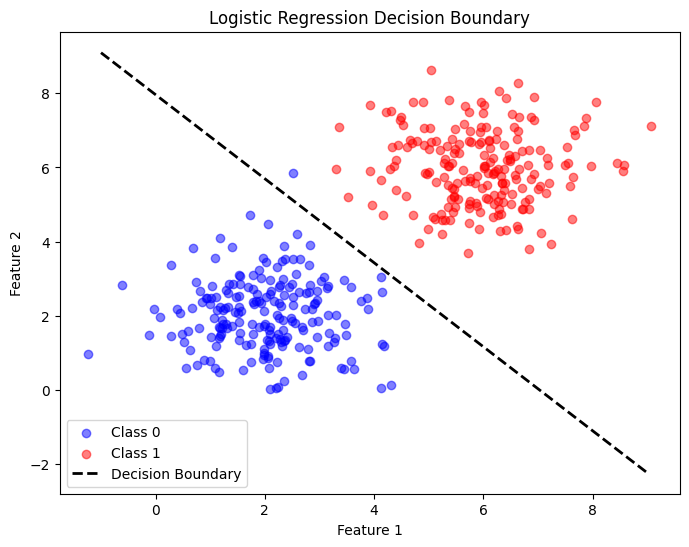

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成两类线性可分的数据 (各200个样本)
# 类 0: 均值 (2, 2)，方差 1
# 类 1: 均值 (6, 6)，方差 1
np.random.seed(42)
X_0 = np.random.randn(200, 2) + np.array([2, 2])
y_0 = np.zeros(200)

X_1 = np.random.randn(200, 2) + np.array([6, 6])
y_1 = np.ones(200)

X_train = np.vstack([X_0, X_1])
y_train = np.hstack([y_0, y_1])

# 新生成100个测试样本 (每类50个)
X_test_0 = np.random.randn(50, 2) + np.array([2, 2])
y_test_0 = np.zeros(50)
X_test_1 = np.random.randn(50, 2) + np.array([6, 6])
y_test_1 = np.ones(50)
X_test = np.vstack([X_test_0, X_test_1])
y_test = np.hstack([y_test_0, y_test_1])

# 2. 定义 sigmoid 函数和二元交叉熵损失
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    n = len(y_true)
    y_pred_clipped = np.clip(y_pred, 1e-12, 1 - 1e-12) # 防止 log 0
    loss = -np.mean(y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
    return loss

# 3. 使用梯度下降法学习参数 w, b (学习率 0.1, 迭代 1000 次)
w = np.random.randn(2)
b = 0.0
lr = 0.1
iterations = 1000
n_samples = len(X_train)

for i in range(iterations):
    z = np.dot(X_train, w) + b
    y_pred = sigmoid(z)
    
    # 梯度
    dz = y_pred - y_train
    dw = np.dot(X_train.T, dz) / n_samples
    db = np.sum(dz) / n_samples
    
    w -= lr * dw
    b -= lr * db

# 4. 绘制决策边界，并计算分类准确率
# 预测测试集
test_z = np.dot(X_test, w) + b
test_pred = sigmoid(test_z)
test_labels = (test_pred >= 0.5).astype(int)
accuracy = np.mean(test_labels == y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# 可视化决策边界
plt.figure(figsize=(8, 6))
# 绘制训练集
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], color='b', label='Class 0', alpha=0.5)
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='r', label='Class 1', alpha=0.5)

# w0*x + w1*y + b = 0  => y = -(w0/w1)*x - b/w1
x_vals = np.linspace(-1, 9, 100)
y_vals = -(w[0] / w[1]) * x_vals - (b / w[1])
plt.plot(x_vals, y_vals, 'k--', label='Decision Boundary', linewidth=2)

plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()